# OCT-C8 → OCT2017 Cross-Dataset Validation — Kaggle GPU

This notebook performs **external cross-dataset validation only**.

### Experimental design
- **Training dataset:** OCT-C8
- **Loaded model:** already-trained `best_CNN_SE_OCT8.keras`
- **External dataset:** OCT2017
- **OCT2017 classes:** CNV, DME, DRUSEN, NORMAL
- **Training on OCT2017:** **NONE**
- **Fine-tuning on OCT2017:** **NONE**
- **Data augmentation during testing:** **NONE**
- **Model selection using OCT2017:** **NONE**

The saved CNN-SE model is loaded directly. The model remains an **8-class OCT-C8 classifier**. For the four-class OCT2017 evaluation, only the corresponding four output neurons are used for the primary four-class prediction.

The notebook also reports the model's native 8-class argmax separately, allowing us to measure whether the model produces an out-of-target OCT-C8 class prediction.


In [1]:
# ============================================================
# CELL 1 — Imports, reproducibility and GPU verification
# ============================================================

import os
import gc
import json
import random
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

from tensorflow import keras
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

try:
    keras.utils.set_random_seed(SEED)
except Exception:
    pass

# GPU memory growth
for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass

print("TensorFlow:", tf.__version__)
print("Keras:", keras.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print("\nGPU is available. Kaggle should be configured with a T4 GPU.")
    try:
        print(tf.config.experimental.get_device_details(gpus[0]))
    except Exception:
        pass
else:
    print("\nWARNING: No GPU detected. The notebook will still run on CPU.")


TensorFlow: 2.20.0
Keras: 3.13.2
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

GPU is available. Kaggle should be configured with a T4 GPU.
{'compute_capability': (7, 5), 'device_name': 'Tesla T4'}


In [5]:
from pathlib import Path

# ============================================================
# KAGGLE DATASET
# ============================================================

KAGGLE_INPUT = Path("/kaggle/input/datasets/paultimothymooney/kermany2018/OCT2017 ")

# OCT2017 TEST SET
OCT2017_TEST_DIR = KAGGLE_INPUT / "test"

# ============================================================
# WORKING DIRECTORIES
# ============================================================

WORK_DIR = Path("/kaggle/working/")
RESULT_DIR = WORK_DIR / "results"
FIG_DIR = WORK_DIR / "figures"
LOG_DIR = WORK_DIR / "logs"

for d in [WORK_DIR, RESULT_DIR, FIG_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ============================================================
# MODEL
# ============================================================

MODEL_FILENAME = "best_CNN_SE_OCT8.keras"

print("Dataset:", KAGGLE_INPUT)
print("OCT2017 test:", OCT2017_TEST_DIR)
print("Test folder exists:", OCT2017_TEST_DIR.exists())

Dataset: /kaggle/input/datasets/paultimothymooney/kermany2018/OCT2017 
OCT2017 test: /kaggle/input/datasets/paultimothymooney/kermany2018/OCT2017 /test
Test folder exists: True


In [7]:
MODEL_PATHS = list(Path("/kaggle/input/models/prd7889/oct-c8-updates/keras/default/1/best_CNN_SE_OCT8.keras").rglob("best_CNN_SE_OCT8.keras"))

print("Model files found:")

for p in MODEL_PATHS:
    print(p)

Model files found:


In [9]:
# ============================================================
# CELL 3 — OCT2017 TEST DIRECTORY
# ============================================================

TARGET_CLASSES = ["CNV", "DME", "DRUSEN", "NORMAL"]

OCT2017_TEST_DIR = KAGGLE_INPUT / "test"

if not OCT2017_TEST_DIR.exists():
    raise FileNotFoundError(
        f"OCT2017 test directory not found: {OCT2017_TEST_DIR}"
    )

print("OCT2017 test directory:", OCT2017_TEST_DIR)

for cls in TARGET_CLASSES:
    class_dir = OCT2017_TEST_DIR / cls

    if not class_dir.exists():
        raise FileNotFoundError(
            f"Missing class directory: {class_dir}"
        )

    print(f"{cls:8s}: {class_dir}")

print("\nOCT2017 test directory verified successfully.")


OCT2017 test directory: /kaggle/input/datasets/paultimothymooney/kermany2018/OCT2017 /test
CNV     : /kaggle/input/datasets/paultimothymooney/kermany2018/OCT2017 /test/CNV
DME     : /kaggle/input/datasets/paultimothymooney/kermany2018/OCT2017 /test/DME
DRUSEN  : /kaggle/input/datasets/paultimothymooney/kermany2018/OCT2017 /test/DRUSEN
NORMAL  : /kaggle/input/datasets/paultimothymooney/kermany2018/OCT2017 /test/NORMAL

OCT2017 test directory verified successfully.


In [10]:
# ============================================================
# CELL 4 — Verify OCT2017 class counts
# ============================================================

IMAGE_EXTENSIONS = {
    ".jpg", ".jpeg", ".png", ".bmp",
    ".tif", ".tiff", ".webp"
}

def list_images(folder):
    folder = Path(folder)
    return sorted(
        p for p in folder.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )

class_rows = []
for cls in TARGET_CLASSES:
    paths = list_images(OCT2017_TEST_DIR / cls)
    class_rows.append({
        "class": cls,
        "count": len(paths)
    })

class_count_df = pd.DataFrame(class_rows)

print(class_count_df.to_string(index=False))
print("\nTotal OCT2017 test images:", int(class_count_df["count"].sum()))

if class_count_df["count"].eq(0).any():
    raise RuntimeError(
        "At least one OCT2017 target class contains zero images. "
        "Check the dataset attachment/path."
    )


 class  count
   CNV    242
   DME    242
DRUSEN    242
NORMAL    242

Total OCT2017 test images: 968


## Exact deterministic preprocessing

The preprocessing is reproduced from the supplied OCT-C8 training notebook:

1. Read as grayscale.
2. Median filtering with kernel size **3**.
3. CLAHE with `clipLimit=2.0`, `tileGridSize=(8,8)`.
4. Aspect-ratio-preserving resize to **224×224**.
5. Zero padding where required.
6. Normalize to `[0,1]`.
7. Replicate the grayscale image into 3 channels.
8. **No augmentation** during OCT2017 testing.

The supplied trained model has an input shape of **224×224×3** and an 8-class softmax output.


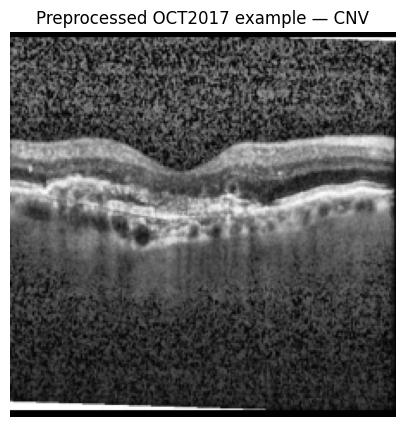

Preprocessed shape: (224, 224, 3)
dtype: float32
min: 0.0
max: 1.0


In [11]:
# ============================================================
# CELL 5 — Exact OCT preprocessing
# ============================================================

IMG_SIZE = (224, 224)

DENOISE_KERNEL = 3
CLAHE_CLIP = 2.0
CLAHE_GRID = (8, 8)

def preprocess_oct(path, img_size=IMG_SIZE):
    path = str(path)

    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        raise ValueError(f"Could not read image: {path}")

    # 1. Mild median denoising
    img = cv2.medianBlur(img, DENOISE_KERNEL)

    # 2. CLAHE
    clahe = cv2.createCLAHE(
        clipLimit=CLAHE_CLIP,
        tileGridSize=CLAHE_GRID
    )
    img = clahe.apply(img)

    # 3. Aspect-ratio-preserving resize + zero padding
    h, w = img.shape
    th, tw = img_size

    scale = min(tw / w, th / h)

    nw = max(1, int(round(w * scale)))
    nh = max(1, int(round(h * scale)))

    img = cv2.resize(
        img,
        (nw, nh),
        interpolation=cv2.INTER_AREA
    )

    canvas = np.zeros(
        (th, tw),
        dtype=np.uint8
    )

    y0 = (th - nh) // 2
    x0 = (tw - nw) // 2

    canvas[
        y0:y0 + nh,
        x0:x0 + nw
    ] = img

    # 4. Normalize to [0, 1]
    img = canvas.astype(np.float32) / 255.0

    # 5. Grayscale -> 3 channels
    img = np.repeat(
        img[..., None],
        3,
        axis=-1
    ).astype(np.float32)

    return img


# Preview one OCT2017 image after the exact preprocessing.
preview_path = list_images(OCT2017_TEST_DIR / TARGET_CLASSES[0])[0]
preview = preprocess_oct(preview_path)

plt.figure(figsize=(7, 5))
plt.imshow(preview[..., 0], cmap="gray")
plt.axis("off")
plt.title(f"Preprocessed OCT2017 example — {TARGET_CLASSES[0]}")
plt.show()

print("Preprocessed shape:", preview.shape)
print("dtype:", preview.dtype)
print("min:", float(preview.min()))
print("max:", float(preview.max()))


In [12]:
# ============================================================
# CELL 6 — Build OCT2017 evaluation table
# ============================================================

records = []

for class_index, cls in enumerate(TARGET_CLASSES):
    class_dir = OCT2017_TEST_DIR / cls

    for p in list_images(class_dir):
        records.append({
            "path": str(p),
            "true_class": cls,
            "true_target_index": class_index
        })

oct2017_df = pd.DataFrame(records)

if len(oct2017_df) == 0:
    raise RuntimeError("No OCT2017 test images were found.")

# Stable deterministic order.
oct2017_df = oct2017_df.sort_values(
    ["true_target_index", "path"]
).reset_index(drop=True)

print("Total evaluation images:", len(oct2017_df))
display(oct2017_df.groupby("true_class").size().to_frame("count"))


Total evaluation images: 968


,count
true_class,
CNV,242
DME,242
DRUSEN,242
NORMAL,242


In [16]:
# ============================================================
# CELL 3 — FIND TRAINED OCT-C8 MODEL
# ============================================================

MODEL_FILENAME = "best_CNN_SE_OCT8.keras"

# Search only for the specific model file.
# This is fast because we are NOT scanning image files.
model_matches = list(
    Path("/kaggle/input/models/prd7889/oct-c8-updates/keras/default/1/").rglob(MODEL_FILENAME)
)

if len(model_matches) == 0:
    raise FileNotFoundError(
        f"Could not find '{MODEL_FILENAME}' under /kaggle/input.\n"
        "Please check that the OCT-C8 model is attached under the "
        "Kaggle MODELS section."
    )

print("Model file(s) found:")

for p in model_matches:
    print("  ", p)

# Use the first matching model
MODEL_PATH = model_matches[0]

print("\nSelected MODEL_PATH:")
print(MODEL_PATH)

Model file(s) found:
   /kaggle/input/models/prd7889/oct-c8-updates/keras/default/1/best_CNN_SE_OCT8.keras

Selected MODEL_PATH:
/kaggle/input/models/prd7889/oct-c8-updates/keras/default/1/best_CNN_SE_OCT8.keras


In [17]:
# ============================================================
# CELL 7 — Load the already-trained OCT-C8 model
# ============================================================

print("Loading model:")
print(MODEL_PATH)

model = keras.models.load_model(
    MODEL_PATH,
    compile=False
)

print("\nModel loaded successfully.")
print("Model name:", model.name)
print("Input shape:", model.input_shape)
print("Output shape:", model.output_shape)
print("Parameter count:", model.count_params())

if tuple(model.input_shape[1:]) != (224, 224, 3):
    raise ValueError(
        f"Unexpected model input shape: {model.input_shape}. "
        "The supplied preprocessing expects 224x224x3."
    )

if int(model.output_shape[-1]) != 8:
    raise ValueError(
        f"Unexpected number of model outputs: {model.output_shape[-1]}. "
        "The OCT-C8 trained model is expected to have 8 outputs."
    )

MODEL_CLASSES = [
    "AMD",
    "CNV",
    "CSR",
    "DME",
    "DR",
    "DRUSEN",
    "MH",
    "NORMAL"
]

# Output neuron indices corresponding to OCT2017's four classes.
TARGET_MODEL_INDICES = {
    "CNV": MODEL_CLASSES.index("CNV"),
    "DME": MODEL_CLASSES.index("DME"),
    "DRUSEN": MODEL_CLASSES.index("DRUSEN"),
    "NORMAL": MODEL_CLASSES.index("NORMAL")
}

TARGET_OUTPUT_INDICES = [
    TARGET_MODEL_INDICES[c]
    for c in TARGET_CLASSES
]

print("\nModel output order:")
for i, c in enumerate(MODEL_CLASSES):
    print(f"{i}: {c}")

print("\nOCT2017 target output indices:", TARGET_OUTPUT_INDICES)


Loading model:
/kaggle/input/models/prd7889/oct-c8-updates/keras/default/1/best_CNN_SE_OCT8.keras


I0000 00:00:1788523282.949607      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788523282.952604      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



Model loaded successfully.
Model name: CNN_SE_OCT8
Input shape: (None, 224, 224, 3)
Output shape: (None, 8)
Parameter count: 1231680

Model output order:
0: AMD
1: CNV
2: CSR
3: DME
4: DR
5: DRUSEN
6: MH
7: NORMAL

OCT2017 target output indices: [1, 3, 5, 7]


In [18]:
# ============================================================
# CELL 8 — Batch preprocessing + GPU inference
# ============================================================

# A fixed batch size is used for efficient inference on the T4.
INFER_BATCH_SIZE = 64

def load_preprocessed_batch(paths):
    batch = np.empty(
        (len(paths), IMG_SIZE[0], IMG_SIZE[1], 3),
        dtype=np.float32
    )

    for i, p in enumerate(paths):
        batch[i] = preprocess_oct(p)

    return batch

all_paths = oct2017_df["path"].tolist()

all_probs = []

start_time = time.perf_counter()

for start in range(0, len(all_paths), INFER_BATCH_SIZE):
    end = min(start + INFER_BATCH_SIZE, len(all_paths))

    batch_paths = all_paths[start:end]
    batch_x = load_preprocessed_batch(batch_paths)

    batch_probs = model.predict(
        batch_x,
        verbose=0
    )

    all_probs.append(batch_probs)

    if (start // INFER_BATCH_SIZE) % 5 == 0 or end == len(all_paths):
        print(f"Processed {end:,}/{len(all_paths):,} images")

all_probs = np.concatenate(all_probs, axis=0)

elapsed = time.perf_counter() - start_time

print("\nInference completed.")
print("Probability matrix shape:", all_probs.shape)
print(f"Total preprocessing + inference time: {elapsed:.3f} seconds")
print(f"Average time per image: {elapsed / len(all_paths) * 1000:.3f} ms")


I0000 00:00:1788523321.324242     228 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Processed 64/968 images
Processed 384/968 images
Processed 704/968 images
Processed 968/968 images

Inference completed.
Probability matrix shape: (968, 8)
Total preprocessing + inference time: 26.096 seconds
Average time per image: 26.959 ms


In [19]:
# ============================================================
# CELL 9 — Native 8-class and restricted 4-class predictions
# ============================================================

y_true = oct2017_df["true_target_index"].to_numpy()

# ------------------------------------------------------------
# Native OCT-C8 8-class argmax
# ------------------------------------------------------------
native_model_indices = np.argmax(
    all_probs,
    axis=1
)

native_model_classes = [
    MODEL_CLASSES[i]
    for i in native_model_indices
]

# Whether the model's native prediction belongs to one of the
# four OCT2017 target classes.
compatible_mask = np.isin(
    native_model_indices,
    TARGET_OUTPUT_INDICES
)

compatibility_rate = float(np.mean(compatible_mask))

# ------------------------------------------------------------
# Primary four-class cross-dataset prediction
# ------------------------------------------------------------
# Extract only CNV/DME/DRUSEN/NORMAL probabilities.
target_probs_raw = all_probs[:, TARGET_OUTPUT_INDICES]

# Renormalize the four target probabilities so that they sum to 1.
target_prob_sums = target_probs_raw.sum(axis=1, keepdims=True)

# Defensive protection against numerical zero.
target_prob_sums = np.maximum(target_prob_sums, 1e-12)

target_probs = target_probs_raw / target_prob_sums

target_pred_indices = np.argmax(
    target_probs,
    axis=1
)

target_pred_classes = [
    TARGET_CLASSES[i]
    for i in target_pred_indices
]

oct2017_df["native_8class_prediction"] = native_model_classes
oct2017_df["native_8class_index"] = native_model_indices
oct2017_df["native_prediction_compatible"] = compatible_mask
oct2017_df["predicted_class"] = target_pred_classes
oct2017_df["predicted_target_index"] = target_pred_indices
oct2017_df["confidence"] = target_probs[
    np.arange(len(target_probs)),
    target_pred_indices
]

# Store target-class probabilities.
for i, cls in enumerate(TARGET_CLASSES):
    oct2017_df[f"prob_{cls}"] = target_probs[:, i]

print("Native 8-class compatibility:", f"{compatibility_rate * 100:.4f}%")
print("Native 8-class out-of-target rate:", f"{(1 - compatibility_rate) * 100:.4f}%")


Native 8-class compatibility: 100.0000%
Native 8-class out-of-target rate: 0.0000%


In [20]:
# ============================================================
# CELL 10 — Final cross-dataset metrics
# ============================================================

accuracy = accuracy_score(
    y_true,
    target_pred_indices
)

precision_macro = precision_score(
    y_true,
    target_pred_indices,
    average="macro",
    zero_division=0
)

recall_macro = recall_score(
    y_true,
    target_pred_indices,
    average="macro",
    zero_division=0
)

f1_macro = f1_score(
    y_true,
    target_pred_indices,
    average="macro",
    zero_division=0
)

precision_weighted = precision_score(
    y_true,
    target_pred_indices,
    average="weighted",
    zero_division=0
)

recall_weighted = recall_score(
    y_true,
    target_pred_indices,
    average="weighted",
    zero_division=0
)

f1_weighted = f1_score(
    y_true,
    target_pred_indices,
    average="weighted",
    zero_division=0
)

# Macro one-vs-rest ROC-AUC.
y_true_bin = label_binarize(
    y_true,
    classes=np.arange(len(TARGET_CLASSES))
)

macro_auc = roc_auc_score(
    y_true_bin,
    target_probs,
    multi_class="ovr",
    average="macro"
)

cm = confusion_matrix(
    y_true,
    target_pred_indices,
    labels=np.arange(len(TARGET_CLASSES))
)

metrics = {
    "training_dataset": "OCT-C8",
    "external_test_dataset": "OCT2017",
    "training_during_test": "NONE",
    "fine_tuning_during_test": "NONE",
    "number_of_images": int(len(y_true)),
    "classes_evaluated": TARGET_CLASSES,
    "accuracy": float(accuracy),
    "macro_precision": float(precision_macro),
    "macro_recall": float(recall_macro),
    "macro_f1": float(f1_macro),
    "weighted_precision": float(precision_weighted),
    "weighted_recall": float(recall_weighted),
    "weighted_f1": float(f1_weighted),
    "macro_roc_auc_ovr": float(macro_auc),
    "native_8class_compatible_prediction_rate": float(compatibility_rate),
    "native_8class_out_of_target_rate": float(1 - compatibility_rate),
    "inference_total_seconds": float(elapsed),
    "inference_ms_per_image": float(elapsed / len(y_true) * 1000),
}

print("=" * 72)
print("FINAL CROSS-DATASET VALIDATION RESULT")
print("=" * 72)

print("Training dataset                 :", metrics["training_dataset"])
print("External test dataset            :", metrics["external_test_dataset"])
print("Training during test             :", metrics["training_during_test"])
print("Fine-tuning during test          :", metrics["fine_tuning_during_test"])
print("Images evaluated                 :", metrics["number_of_images"])
print("Classes                          :", ", ".join(TARGET_CLASSES))
print()
print(f"Accuracy                         : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Macro Precision                  : {precision_macro:.4f}")
print(f"Macro Recall                     : {recall_macro:.4f}")
print(f"Macro F1-score                   : {f1_macro:.4f}")
print(f"Weighted Precision               : {precision_weighted:.4f}")
print(f"Weighted Recall                  : {recall_weighted:.4f}")
print(f"Weighted F1-score                : {f1_weighted:.4f}")
print(f"Macro ROC-AUC (OvR)              : {macro_auc:.4f}")
print(f"Native 8-class compatible        : {compatibility_rate*100:.2f}%")
print(f"Native 8-class out-of-target     : {(1-compatibility_rate)*100:.2f}%")


FINAL CROSS-DATASET VALIDATION RESULT
Training dataset                 : OCT-C8
External test dataset            : OCT2017
Training during test             : NONE
Fine-tuning during test          : NONE
Images evaluated                 : 968
Classes                          : CNV, DME, DRUSEN, NORMAL

Accuracy                         : 0.9938 (99.38%)
Macro Precision                  : 0.9939
Macro Recall                     : 0.9938
Macro F1-score                   : 0.9938
Weighted Precision               : 0.9939
Weighted Recall                  : 0.9938
Weighted F1-score                : 0.9938
Macro ROC-AUC (OvR)              : 0.9999
Native 8-class compatible        : 100.00%
Native 8-class out-of-target     : 0.00%


In [21]:
# ============================================================
# CELL 11 — Class-wise classification report
# ============================================================

report_dict = classification_report(
    y_true,
    target_pred_indices,
    labels=np.arange(len(TARGET_CLASSES)),
    target_names=TARGET_CLASSES,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).T

print(report_df.round(4).to_string())

report_df.to_csv(
    RESULT_DIR / "OCT2017_cross_dataset_classification_report.csv"
)

print("\nClassification report saved.")


              precision  recall  f1-score   support
CNV              0.9837  1.0000    0.9918  242.0000
DME              1.0000  0.9876    0.9938  242.0000
DRUSEN           0.9917  0.9917    0.9917  242.0000
NORMAL           1.0000  0.9959    0.9979  242.0000
accuracy         0.9938  0.9938    0.9938    0.9938
macro avg        0.9939  0.9938    0.9938  968.0000
weighted avg     0.9939  0.9938    0.9938  968.0000

Classification report saved.


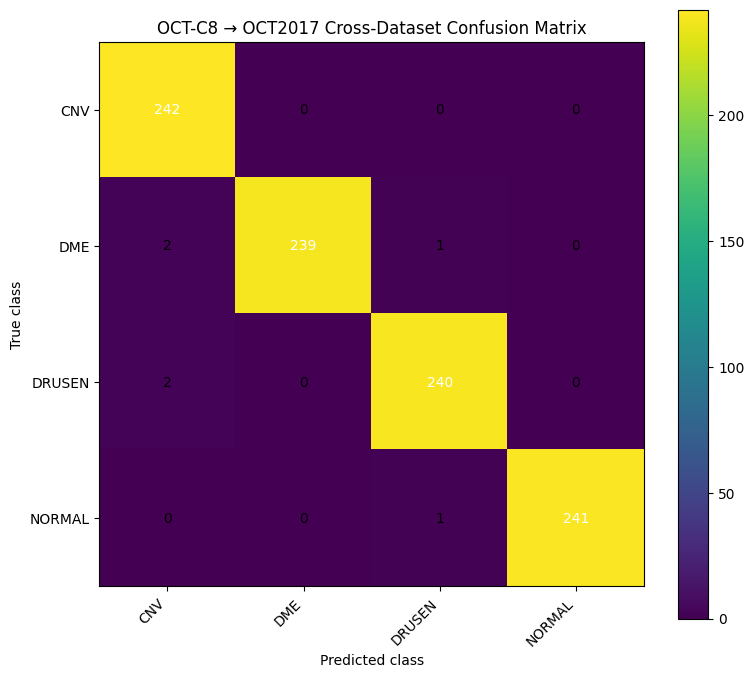

Confusion matrix saved: /kaggle/working/figures/OCT2017_cross_dataset_confusion_matrix.png


In [22]:
# ============================================================
# CELL 12 — Confusion matrix
# ============================================================

plt.figure(figsize=(8, 7))

plt.imshow(cm)

plt.title("OCT-C8 → OCT2017 Cross-Dataset Confusion Matrix")
plt.xlabel("Predicted class")
plt.ylabel("True class")

plt.xticks(
    range(len(TARGET_CLASSES)),
    TARGET_CLASSES,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(TARGET_CLASSES)),
    TARGET_CLASSES
)

plt.colorbar()

threshold = cm.max() / 2 if cm.max() else 0

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            color="white" if cm[i, j] > threshold else "black"
        )

plt.tight_layout()

cm_path = FIG_DIR / "OCT2017_cross_dataset_confusion_matrix.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

pd.DataFrame(
    cm,
    index=TARGET_CLASSES,
    columns=TARGET_CLASSES
).to_csv(
    RESULT_DIR / "OCT2017_cross_dataset_confusion_matrix.csv"
)

print("Confusion matrix saved:", cm_path)


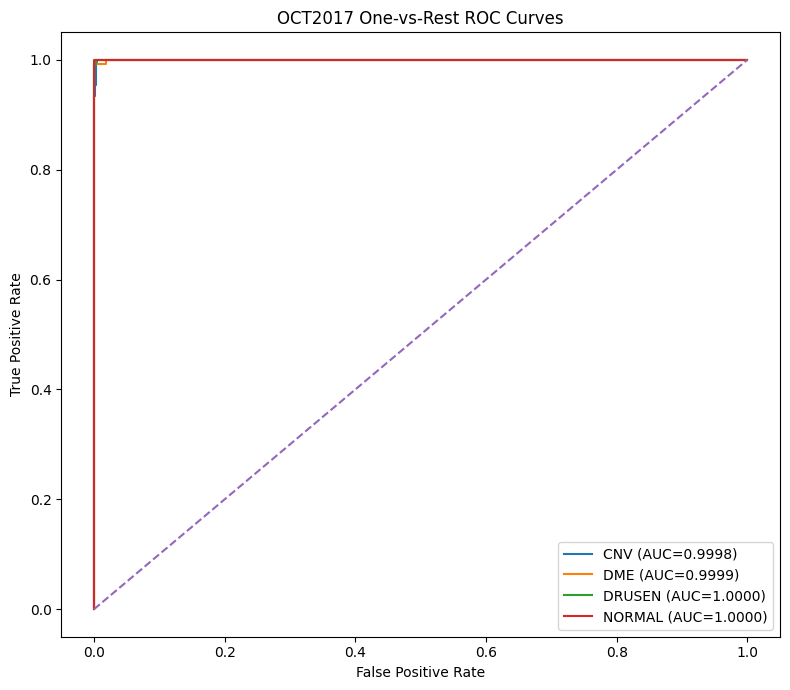

Macro ROC-AUC: 0.999917
ROC figure saved: /kaggle/working/figures/OCT2017_cross_dataset_ROC_curves.png


In [23]:
# ============================================================
# CELL 13 — ROC curves and macro ROC-AUC
# ============================================================

plt.figure(figsize=(8, 7))

for i, cls in enumerate(TARGET_CLASSES):
    fpr, tpr, _ = roc_curve(
        y_true_bin[:, i],
        target_probs[:, i]
    )

    class_auc = roc_auc_score(
        y_true_bin[:, i],
        target_probs[:, i]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{cls} (AUC={class_auc:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("OCT2017 One-vs-Rest ROC Curves")
plt.legend(loc="lower right")
plt.tight_layout()

roc_path = FIG_DIR / "OCT2017_cross_dataset_ROC_curves.png"
plt.savefig(roc_path, dpi=300, bbox_inches="tight")
plt.show()

print("Macro ROC-AUC:", f"{macro_auc:.6f}")
print("ROC figure saved:", roc_path)


In [24]:
# ============================================================
# CELL 14 — Save complete per-image predictions
# ============================================================

prediction_columns = [
    "path",
    "true_class",
    "true_target_index",
    "native_8class_prediction",
    "native_8class_index",
    "native_prediction_compatible",
    "predicted_class",
    "predicted_target_index",
    "confidence",
]

prediction_columns += [
    f"prob_{cls}"
    for cls in TARGET_CLASSES
]

predictions_path = RESULT_DIR / "OCT2017_cross_dataset_predictions.csv"

oct2017_df[prediction_columns].to_csv(
    predictions_path,
    index=False
)

print("Per-image predictions saved:", predictions_path)

print("\nFirst five predictions:")
display(
    oct2017_df[prediction_columns].head()
)


Per-image predictions saved: /kaggle/working/results/OCT2017_cross_dataset_predictions.csv

First five predictions:


,path,true_class,true_target_index,native_8class_prediction,native_8class_index,native_prediction_compatible,predicted_class,predicted_target_index,confidence,prob_CNV,prob_DME,prob_DRUSEN,prob_NORMAL
0,/kaggle/input/datasets/paultimothymooney/kerma...,CNV,0,CNV,1,True,CNV,0,0.984506,0.984506,0.005857,0.002371,0.007267
1,/kaggle/input/datasets/paultimothymooney/kerma...,CNV,0,CNV,1,True,CNV,0,0.984044,0.984044,0.007169,0.001663,0.007124
2,/kaggle/input/datasets/paultimothymooney/kerma...,CNV,0,CNV,1,True,CNV,0,0.969583,0.969583,0.022426,0.003728,0.004263
3,/kaggle/input/datasets/paultimothymooney/kerma...,CNV,0,CNV,1,True,CNV,0,0.985283,0.985283,0.006500,0.001610,0.006607
4,/kaggle/input/datasets/paultimothymooney/kerma...,CNV,0,CNV,1,True,CNV,0,0.963672,0.963672,0.031176,0.002853,0.002299


In [25]:
# ============================================================
# CELL 15 — Save final metrics and experiment configuration
# ============================================================

metrics_path = RESULT_DIR / "OCT2017_cross_dataset_metrics.json"

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2)

config = {
    "model_path": str(MODEL_PATH),
    "model_input_shape": list(model.input_shape),
    "model_output_shape": list(model.output_shape),
    "model_classes": MODEL_CLASSES,
    "oct2017_classes": TARGET_CLASSES,
    "target_output_indices": TARGET_OUTPUT_INDICES,
    "image_size": list(IMG_SIZE),
    "median_kernel": DENOISE_KERNEL,
    "clahe_clip": CLAHE_CLIP,
    "clahe_grid": list(CLAHE_GRID),
    "augmentation": False,
    "training": False,
    "fine_tuning": False,
    "seed": SEED,
    "inference_batch_size": INFER_BATCH_SIZE,
}

config_path = LOG_DIR / "experiment_configuration.json"

with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=2)

print("Metrics:", metrics_path)
print("Configuration:", config_path)


Metrics: /kaggle/working/results/OCT2017_cross_dataset_metrics.json
Configuration: /kaggle/working/logs/experiment_configuration.json


# Scientific interpretation

The **primary cross-dataset accuracy** is calculated by comparing the true OCT2017 labels against predictions made using only the four corresponding OCT-C8 output classes:

**CNV, DME, DRUSEN, NORMAL**

This is appropriate for the four-class external evaluation because OCT2017 contains no AMD, CSR, DR, or MH ground-truth categories.

The notebook additionally reports:

- **Native 8-class compatible prediction rate:** percentage of OCT2017 images for which the original 8-class model's highest-probability output is one of the four OCT2017 classes.
- **Native 8-class out-of-target rate:** percentage for which the model's native top prediction is AMD, CSR, DR, or MH.

For the research paper, the four-class accuracy should be reported together with class-wise precision, recall, F1-score, macro ROC-AUC, confusion matrix, and—if desired—confidence intervals or repeated-seed results.

**Important:** OCT2017 is never used to train, fine-tune, select hyperparameters, or select the best model in this notebook.


In [27]:
from statsmodels.stats.proportion import proportion_confint
import numpy as np

# Number of correct predictions
correct = np.sum(np.array(y_true) == np.array(target_pred_indices))

# Total number of evaluated images
total = len(target_pred_indices)

# Accuracy
accuracy = correct / total

# 95% Wilson confidence interval
ci_low, ci_high = proportion_confint(
    count=correct,
    nobs=total,
    alpha=0.05,
    method="wilson"
)

print("=" * 70)
print("95% CONFIDENCE INTERVAL — OCT2017")
print("=" * 70)

print(f"Correct predictions : {correct}")
print(f"Total images        : {total}")
print(f"Accuracy            : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"95% CI              : {ci_low*100:.2f}% – {ci_high*100:.2f}%")
print("=" * 70)

95% CONFIDENCE INTERVAL — OCT2017
Correct predictions : 962
Total images        : 968
Accuracy            : 0.9938 (99.38%)
95% CI              : 98.65% – 99.72%


In [28]:
# ================================================================
# COMPREHENSIVE STATISTICAL ANALYSIS — OCT2017
# External Cross-Dataset Validation
# ================================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    matthews_corrcoef,
    cohen_kappa_score,
    roc_auc_score
)

from statsmodels.stats.proportion import proportion_confint


# ================================================================
# 1. BASIC SETTINGS
# ================================================================

CLASS_NAMES = ["CNV", "DME", "DRUSEN", "NORMAL"]

y_true_np = np.asarray(y_true)
y_pred_np = np.asarray(target_pred_indices)

assert len(y_true_np) == len(y_pred_np), (
    "y_true and target_pred_indices must have the same length."
)

total = len(y_true_np)

# Number of correct predictions
correct = np.sum(y_true_np == y_pred_np)

# Accuracy
accuracy = correct / total


# ================================================================
# 2. 95% WILSON CONFIDENCE INTERVAL FOR ACCURACY
# ================================================================

acc_ci_low, acc_ci_high = proportion_confint(
    count=correct,
    nobs=total,
    alpha=0.05,
    method="wilson"
)


# ================================================================
# 3. CONFUSION MATRIX
# ================================================================

cm = confusion_matrix(
    y_true_np,
    y_pred_np,
    labels=np.arange(len(CLASS_NAMES))
)


# ================================================================
# 4. OVERALL CLASSIFICATION METRICS
# ================================================================

macro_precision = precision_score(
    y_true_np,
    y_pred_np,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_true_np,
    y_pred_np,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_true_np,
    y_pred_np,
    average="macro",
    zero_division=0
)

weighted_precision = precision_score(
    y_true_np,
    y_pred_np,
    average="weighted",
    zero_division=0
)

weighted_recall = recall_score(
    y_true_np,
    y_pred_np,
    average="weighted",
    zero_division=0
)

weighted_f1 = f1_score(
    y_true_np,
    y_pred_np,
    average="weighted",
    zero_division=0
)

# Matthews Correlation Coefficient
mcc = matthews_corrcoef(
    y_true_np,
    y_pred_np
)

# Cohen's Kappa
cohen_kappa = cohen_kappa_score(
    y_true_np,
    y_pred_np
)


# ================================================================
# 5. PER-CLASS STATISTICAL METRICS
# ================================================================

rows = []

for i, class_name in enumerate(CLASS_NAMES):

    # True Positives
    TP = cm[i, i]

    # False Negatives
    FN = np.sum(cm[i, :]) - TP

    # False Positives
    FP = np.sum(cm[:, i]) - TP

    # True Negatives
    TN = np.sum(cm) - TP - FN - FP

    # Support
    support = TP + FN

    # Precision / PPV
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0

    # Sensitivity / Recall
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0.0

    # Specificity
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0

    # Negative Predictive Value
    npv = TN / (TN + FN) if (TN + FN) > 0 else 0.0

    # F1-score
    f1 = (
        2 * precision * sensitivity /
        (precision + sensitivity)
        if (precision + sensitivity) > 0
        else 0.0
    )

    # ------------------------------------------------------------
    # 95% CI for sensitivity
    # ------------------------------------------------------------

    sens_ci_low, sens_ci_high = proportion_confint(
        count=TP,
        nobs=TP + FN,
        alpha=0.05,
        method="wilson"
    )

    # ------------------------------------------------------------
    # 95% CI for specificity
    # ------------------------------------------------------------

    spec_ci_low, spec_ci_high = proportion_confint(
        count=TN,
        nobs=TN + FP,
        alpha=0.05,
        method="wilson"
    )

    rows.append({
        "Class": class_name,
        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "Support": support,
        "Precision": precision,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "NPV": npv,
        "F1-score": f1,
        "Sensitivity 95% CI": (
            f"{sens_ci_low*100:.2f}%–{sens_ci_high*100:.2f}%"
        ),
        "Specificity 95% CI": (
            f"{spec_ci_low*100:.2f}%–{spec_ci_high*100:.2f}%"
        )
    })


per_class_stats = pd.DataFrame(rows)


# ================================================================
# 6. BOOTSTRAP CONFIDENCE INTERVAL FOR MACRO-F1
# ================================================================

rng = np.random.default_rng(42)

N_BOOTSTRAP = 10000

bootstrap_f1 = np.zeros(N_BOOTSTRAP)

for b in range(N_BOOTSTRAP):

    indices = rng.integers(
        0,
        total,
        size=total
    )

    boot_true = y_true_np[indices]
    boot_pred = y_pred_np[indices]

    bootstrap_f1[b] = f1_score(
        boot_true,
        boot_pred,
        average="macro",
        labels=np.arange(len(CLASS_NAMES)),
        zero_division=0
    )


f1_ci_low = np.percentile(
    bootstrap_f1,
    2.5
)

f1_ci_high = np.percentile(
    bootstrap_f1,
    97.5
)


# ================================================================
# 7. BOOTSTRAP ROC-AUC
# ================================================================
#
# IMPORTANT:
# This section requires probability predictions.
#
# The variable expected here is:
# target_probs
#
# target_probs shape should be:
# (number_of_images, 4)
#
# Columns:
# CNV, DME, DRUSEN, NORMAL
#
# If target_probs does not exist, ROC-AUC bootstrap
# will be skipped rather than causing the entire cell to fail.
# ================================================================

roc_auc = None
auc_ci_low = None
auc_ci_high = None

if "target_probs" in globals():

    target_probs_np = np.asarray(target_probs)

    if target_probs_np.shape[0] == total:

        # Point estimate
        roc_auc = roc_auc_score(
            y_true_np,
            target_probs_np,
            multi_class="ovr",
            average="macro",
            labels=np.arange(len(CLASS_NAMES))
        )

        bootstrap_auc = []

        for b in range(N_BOOTSTRAP):

            indices = rng.integers(
                0,
                total,
                size=total
            )

            boot_true = y_true_np[indices]
            boot_probs = target_probs_np[indices]

            # AUC cannot be calculated if bootstrap sample
            # does not contain all four classes.
            if len(np.unique(boot_true)) < len(CLASS_NAMES):
                continue

            try:

                boot_auc = roc_auc_score(
                    boot_true,
                    boot_probs,
                    multi_class="ovr",
                    average="macro",
                    labels=np.arange(len(CLASS_NAMES))
                )

                bootstrap_auc.append(boot_auc)

            except ValueError:
                continue

        if len(bootstrap_auc) > 0:

            auc_ci_low = np.percentile(
                bootstrap_auc,
                2.5
            )

            auc_ci_high = np.percentile(
                bootstrap_auc,
                97.5
            )


# ================================================================
# 8. PRINT FINAL STATISTICAL SUMMARY
# ================================================================

print("=" * 80)
print("COMPREHENSIVE STATISTICAL ANALYSIS — OCT2017")
print("EXTERNAL CROSS-DATASET VALIDATION")
print("=" * 80)

print(f"Total images                 : {total}")
print(f"Correct predictions          : {correct}")
print(f"Incorrect predictions        : {total - correct}")

print()
print(f"Accuracy                     : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(
    f"95% Wilson CI                : "
    f"{acc_ci_low*100:.2f}% – {acc_ci_high*100:.2f}%"
)

print()
print(f"Macro Precision              : {macro_precision:.4f} ({macro_precision*100:.2f}%)")
print(f"Macro Recall / Sensitivity   : {macro_recall:.4f} ({macro_recall*100:.2f}%)")
print(f"Macro F1-score               : {macro_f1:.4f} ({macro_f1*100:.2f}%)")

print()
print(f"Weighted Precision           : {weighted_precision:.4f} ({weighted_precision*100:.2f}%)")
print(f"Weighted Recall              : {weighted_recall:.4f} ({weighted_recall*100:.2f}%)")
print(f"Weighted F1-score            : {weighted_f1:.4f} ({weighted_f1*100:.2f}%)")

print()
print(f"Matthews Correlation Coeff.  : {mcc:.4f}")
print(f"Cohen's Kappa                : {cohen_kappa:.4f}")

print()
print(
    f"Macro-F1 Bootstrap 95% CI    : "
    f"{f1_ci_low*100:.2f}% – {f1_ci_high*100:.2f}%"
)

if roc_auc is not None:

    print(
        f"Macro ROC-AUC                : "
        f"{roc_auc:.4f}"
    )

    if auc_ci_low is not None:

        print(
            f"Macro ROC-AUC Bootstrap CI   : "
            f"{auc_ci_low:.4f} – {auc_ci_high:.4f}"
        )

else:

    print("Macro ROC-AUC                : Not calculated")
    print("ROC-AUC Bootstrap CI         : target_probs not available")

print("=" * 80)


# ================================================================
# 9. PER-CLASS RESULTS
# ================================================================

print()
print("=" * 80)
print("PER-CLASS STATISTICAL ANALYSIS")
print("=" * 80)

display(
    per_class_stats.style.format({
        "Precision": "{:.4f}",
        "Sensitivity": "{:.4f}",
        "Specificity": "{:.4f}",
        "NPV": "{:.4f}",
        "F1-score": "{:.4f}"
    })
)

COMPREHENSIVE STATISTICAL ANALYSIS — OCT2017
EXTERNAL CROSS-DATASET VALIDATION
Total images                 : 968
Correct predictions          : 962
Incorrect predictions        : 6

Accuracy                     : 0.9938 (99.38%)
95% Wilson CI                : 98.65% – 99.72%

Macro Precision              : 0.9939 (99.39%)
Macro Recall / Sensitivity   : 0.9938 (99.38%)
Macro F1-score               : 0.9938 (99.38%)

Weighted Precision           : 0.9939 (99.39%)
Weighted Recall              : 0.9938 (99.38%)
Weighted F1-score            : 0.9938 (99.38%)

Matthews Correlation Coeff.  : 0.9918
Cohen's Kappa                : 0.9917

Macro-F1 Bootstrap 95% CI    : 98.85% – 99.80%
Macro ROC-AUC                : 0.9999
Macro ROC-AUC Bootstrap CI   : 0.9998 – 1.0000

PER-CLASS STATISTICAL ANALYSIS


,Class,TP,TN,FP,FN,Support,Precision,Sensitivity,Specificity,NPV,F1-score,Sensitivity 95% CI,Specificity 95% CI
0,CNV,242,722,4,0,242,0.9837,1.0000,0.9945,1.0000,0.9918,98.44%–100.00%,98.59%–99.79%
1,DME,239,726,0,3,242,1.0000,0.9876,1.0000,0.9959,0.9938,96.42%–99.58%,99.47%–100.00%
2,DRUSEN,240,724,2,2,242,0.9917,0.9917,0.9972,0.9972,0.9917,97.04%–99.77%,99.00%–99.92%
3,NORMAL,241,726,0,1,242,1.0000,0.9959,1.0000,0.9986,0.9979,97.70%–99.93%,99.47%–100.00%


In [29]:
# ================================================================
# VERIFY OCT2017 PROBABILITY OUTPUTS
# ================================================================

import numpy as np

y_true_np = np.asarray(y_true)
y_pred_np = np.asarray(target_pred_indices)
target_probs_np = np.asarray(target_probs)

print("y_true shape            :", y_true_np.shape)
print("target_pred_indices    :", y_pred_np.shape)
print("target_probs shape     :", target_probs_np.shape)

print("\nFirst probability vector:")
print(target_probs_np[0])

print("\nProbability sum check:")
print("Minimum sum:", target_probs_np.sum(axis=1).min())
print("Maximum sum:", target_probs_np.sum(axis=1).max())

y_true shape            : (968,)
target_pred_indices    : (968,)
target_probs shape     : (968, 4)

First probability vector:
[0.9845059  0.0058565  0.00237092 0.00726675]

Probability sum check:
Minimum sum: 0.9999999
Maximum sum: 1.0000001


In [30]:
# ================================================================
# CALIBRATION ANALYSIS — OCT2017
# ================================================================

import numpy as np
import pandas as pd

from sklearn.metrics import brier_score_loss

CLASS_NAMES = ["CNV", "DME", "DRUSEN", "NORMAL"]

# ------------------------------------------------
# Basic arrays
# ------------------------------------------------

y_true_np = np.asarray(y_true)
y_pred_np = np.asarray(target_pred_indices)
probs = np.asarray(target_probs)

# Predicted confidence
confidence = np.max(probs, axis=1)

# Correct / incorrect
correct_prediction = (
    y_true_np == y_pred_np
)

# ================================================================
# 1. EXPECTED CALIBRATION ERROR (ECE)
# ================================================================

N_BINS = 10

bin_edges = np.linspace(0.0, 1.0, N_BINS + 1)

calibration_rows = []

ece = 0.0
mce = 0.0

for i in range(N_BINS):

    lower = bin_edges[i]
    upper = bin_edges[i + 1]

    if i == N_BINS - 1:

        mask = (
            (confidence >= lower) &
            (confidence <= upper)
        )

    else:

        mask = (
            (confidence >= lower) &
            (confidence < upper)
        )

    count = np.sum(mask)

    if count == 0:
        continue

    bin_accuracy = np.mean(
        correct_prediction[mask]
    )

    bin_confidence = np.mean(
        confidence[mask]
    )

    bin_error = abs(
        bin_accuracy - bin_confidence
    )

    bin_weight = count / len(y_true_np)

    ece += bin_weight * bin_error

    mce = max(
        mce,
        bin_error
    )

    calibration_rows.append({
        "Bin": f"{lower:.1f}–{upper:.1f}",
        "Samples": count,
        "Mean Confidence": bin_confidence,
        "Accuracy": bin_accuracy,
        "Absolute Error": bin_error
    })


calibration_df = pd.DataFrame(
    calibration_rows
)


# ================================================================
# 2. MULTICLASS BRIER SCORE
# ================================================================

# One-hot encoded ground truth
y_true_onehot = np.eye(
    len(CLASS_NAMES)
)[y_true_np]

brier_score = np.mean(
    np.sum(
        (probs - y_true_onehot) ** 2,
        axis=1
    )
)


# ================================================================
# 3. PRINT RESULTS
# ================================================================

print("=" * 75)
print("CALIBRATION ANALYSIS — OCT2017")
print("=" * 75)

print(f"Expected Calibration Error (ECE) : {ece:.6f}")
print(f"Maximum Calibration Error (MCE)  : {mce:.6f}")
print(f"Multiclass Brier Score            : {brier_score:.6f}")

print()
print("Interpretation:")
print("ECE closer to 0  = better calibration")
print("MCE closer to 0  = better worst-bin calibration")
print("Brier closer to 0 = better probabilistic accuracy")

print("=" * 75)

display(
    calibration_df.style.format({
        "Mean Confidence": "{:.4f}",
        "Accuracy": "{:.4f}",
        "Absolute Error": "{:.4f}"
    })
)

CALIBRATION ANALYSIS — OCT2017
Expected Calibration Error (ECE) : 0.024623
Maximum Calibration Error (MCE)  : 0.248466
Multiclass Brier Score            : 0.011059

Interpretation:
ECE closer to 0  = better calibration
MCE closer to 0  = better worst-bin calibration
Brier closer to 0 = better probabilistic accuracy


,Bin,Samples,Mean Confidence,Accuracy,Absolute Error
0,0.4–0.5,2,0.4386,0.5000,0.0614
1,0.5–0.6,2,0.5689,0.5000,0.0689
2,0.6–0.7,5,0.6311,0.6000,0.0311
3,0.7–0.8,6,0.7515,1.0000,0.2485
4,0.8–0.9,27,0.8652,1.0000,0.1348
5,0.9–1.0,926,0.9781,0.9978,0.0197


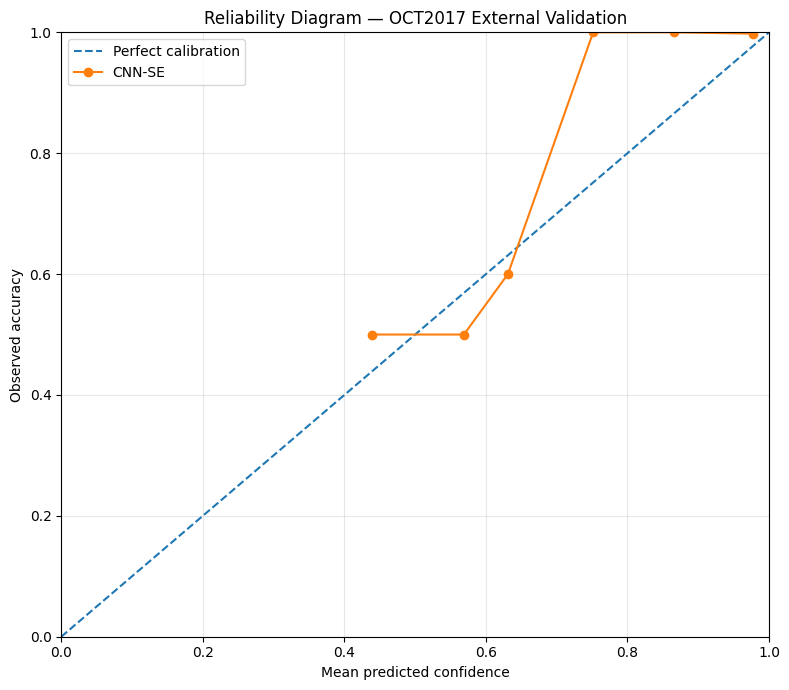

In [31]:
# ================================================================
# RELIABILITY DIAGRAM — OCT2017
# ================================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 7))

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.plot(
    calibration_df["Mean Confidence"],
    calibration_df["Accuracy"],
    marker="o",
    label="CNN-SE"
)

plt.xlabel("Mean predicted confidence")
plt.ylabel("Observed accuracy")
plt.title("Reliability Diagram — OCT2017 External Validation")

plt.xlim(0, 1)
plt.ylim(0, 1)

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    "OCT2017_reliability_diagram.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

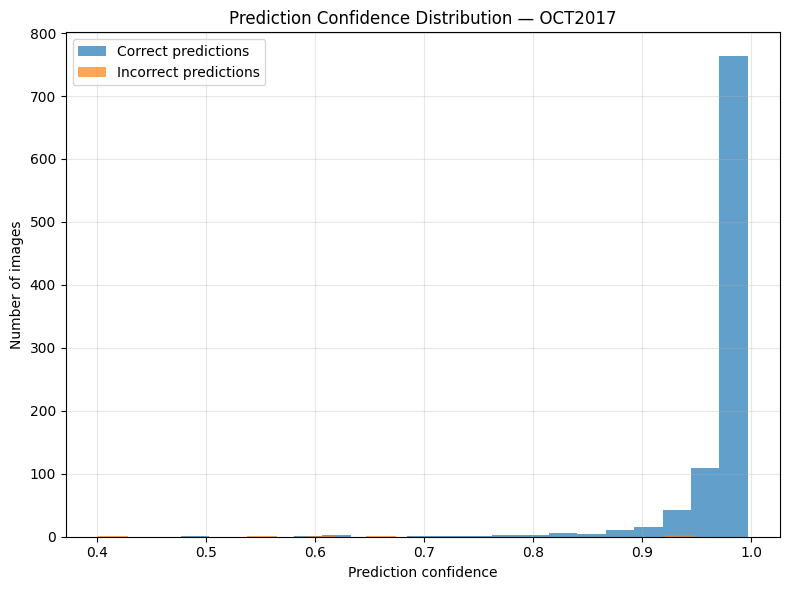

Correct predictions: 962
Incorrect predictions: 6
Mean confidence — correct   : 0.9716
Mean confidence — incorrect : 0.6853


In [32]:
# ================================================================
# CONFIDENCE DISTRIBUTION — OCT2017
# ================================================================

import matplotlib.pyplot as plt

correct_confidence = confidence[
    correct_prediction
]

incorrect_confidence = confidence[
    ~correct_prediction
]

plt.figure(figsize=(8, 6))

plt.hist(
    correct_confidence,
    bins=20,
    alpha=0.7,
    label="Correct predictions"
)

plt.hist(
    incorrect_confidence,
    bins=20,
    alpha=0.7,
    label="Incorrect predictions"
)

plt.xlabel("Prediction confidence")
plt.ylabel("Number of images")
plt.title("Prediction Confidence Distribution — OCT2017")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    "OCT2017_confidence_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Correct predictions:", len(correct_confidence))
print("Incorrect predictions:", len(incorrect_confidence))

print(
    f"Mean confidence — correct   : "
    f"{correct_confidence.mean():.4f}"
)

if len(incorrect_confidence) > 0:

    print(
        f"Mean confidence — incorrect : "
        f"{incorrect_confidence.mean():.4f}"
    )

In [33]:
# ================================================================
# ERROR ANALYSIS — IDENTIFY MISCLASSIFIED OCT2017 IMAGES
# ================================================================

error_mask = (
    y_true_np != y_pred_np
)

error_indices = np.where(
    error_mask
)[0]

print("=" * 75)
print("OCT2017 MISCLASSIFICATION ANALYSIS")
print("=" * 75)

print(f"Total images       : {len(y_true_np)}")
print(f"Correct predictions: {np.sum(~error_mask)}")
print(f"Errors             : {len(error_indices)}")

print("=" * 75)


error_rows = []

for idx in error_indices:

    true_class = CLASS_NAMES[
        y_true_np[idx]
    ]

    predicted_class = CLASS_NAMES[
        y_pred_np[idx]
    ]

    predicted_confidence = np.max(
        probs[idx]
    )

    true_class_probability = probs[
        idx,
        y_true_np[idx]
    ]

    error_rows.append({

        "Index": idx,

        "True Class": true_class,

        "Predicted Class": predicted_class,

        "Confidence": predicted_confidence,

        "True-Class Probability": true_class_probability,

        "CNV Probability": probs[idx, 0],

        "DME Probability": probs[idx, 1],

        "DRUSEN Probability": probs[idx, 2],

        "NORMAL Probability": probs[idx, 3]
    })


error_df = pd.DataFrame(
    error_rows
)

display(
    error_df.style.format({
        "Confidence": "{:.4f}",
        "True-Class Probability": "{:.4f}",
        "CNV Probability": "{:.4f}",
        "DME Probability": "{:.4f}",
        "DRUSEN Probability": "{:.4f}",
        "NORMAL Probability": "{:.4f}"
    })
)

OCT2017 MISCLASSIFICATION ANALYSIS
Total images       : 968
Correct predictions: 962
Errors             : 6


,Index,True Class,Predicted Class,Confidence,True-Class Probability,CNV Probability,DME Probability,DRUSEN Probability,NORMAL Probability
0,287,DME,CNV,0.9473,0.0455,0.9473,0.0455,0.0033,0.0039
1,331,DME,CNV,0.9332,0.0466,0.9332,0.0466,0.0143,0.0060
2,364,DME,DRUSEN,0.4006,0.3976,0.1960,0.3976,0.4006,0.0058
3,700,DRUSEN,CNV,0.6687,0.3256,0.6687,0.0026,0.3256,0.0031
4,723,DRUSEN,CNV,0.6090,0.3725,0.6090,0.0159,0.3725,0.0026
5,782,NORMAL,DRUSEN,0.5530,0.4314,0.0090,0.0065,0.5530,0.4314


In [39]:
# ================================================================
# FIND THE SIX MISCLASSIFIED OCT2017 IMAGES
# ================================================================

from pathlib import Path
import pandas as pd
import numpy as np

OCT2017_TEST_DIR = KAGGLE_INPUT / "test"
CLASS_NAMES = ["CNV", "DME", "DRUSEN", "NORMAL"]

# ------------------------------------------------
# Reconstruct image paths in the same class order
# ------------------------------------------------

image_paths = []

for class_idx, class_name in enumerate(CLASS_NAMES):

    class_dir = OCT2017_TEST_DIR / class_name

    files = sorted([
        p for p in class_dir.iterdir()
        if p.suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"]
    ])

    for path in files:

        image_paths.append({
            "path": str(path),
            "true_class": class_name,
            "true_idx": class_idx
        })

image_df = pd.DataFrame(image_paths)

print("Total images found:", len(image_df))

# ------------------------------------------------
# IMPORTANT:
# Verify that the reconstructed order matches y_true
# ------------------------------------------------

if len(image_df) != len(y_true):
    raise ValueError(
        f"Image count mismatch: "
        f"{len(image_df)} paths vs {len(y_true)} labels"
    )

reconstructed_true = image_df["true_idx"].to_numpy()

if not np.array_equal(
    reconstructed_true,
    np.asarray(y_true)
):
    raise ValueError(
        "WARNING: Image path order does not match y_true. "
        "Do NOT use these paths for error analysis until ordering is fixed."
    )

print("✓ Image ordering matches y_true")

# ------------------------------------------------
# Identify errors
# ------------------------------------------------

error_mask = (
    np.asarray(y_true) !=
    np.asarray(target_pred_indices)
)

error_indices = np.where(error_mask)[0]

print()
print("=" * 75)
print("SIX MISCLASSIFIED OCT2017 IMAGES")
print("=" * 75)

print("Number of errors:", len(error_indices))

error_rows = []

for idx in error_indices:

    true_idx = int(y_true[idx])
    pred_idx = int(target_pred_indices[idx])

    error_rows.append({
        "Index": int(idx),
        "Image Path": image_df.iloc[idx]["path"],
        "True Class": CLASS_NAMES[true_idx],
        "Predicted Class": CLASS_NAMES[pred_idx],
        "Confidence": float(np.max(target_probs[idx])),
        "True Class Probability": float(
            target_probs[idx][true_idx]
        )
    })

error_df = pd.DataFrame(error_rows)

display(error_df)

Total images found: 968
✓ Image ordering matches y_true

SIX MISCLASSIFIED OCT2017 IMAGES
Number of errors: 6


,Index,Image Path,True Class,Predicted Class,Confidence,True Class Probability
0,287,/kaggle/input/datasets/paultimothymooney/kerma...,DME,CNV,0.947322,0.045476
1,331,/kaggle/input/datasets/paultimothymooney/kerma...,DME,CNV,0.933150,0.046563
2,364,/kaggle/input/datasets/paultimothymooney/kerma...,DME,DRUSEN,0.400631,0.397553
3,700,/kaggle/input/datasets/paultimothymooney/kerma...,DRUSEN,CNV,0.668697,0.325585
4,723,/kaggle/input/datasets/paultimothymooney/kerma...,DRUSEN,CNV,0.608994,0.372536
5,782,/kaggle/input/datasets/paultimothymooney/kerma...,NORMAL,DRUSEN,0.553048,0.431423


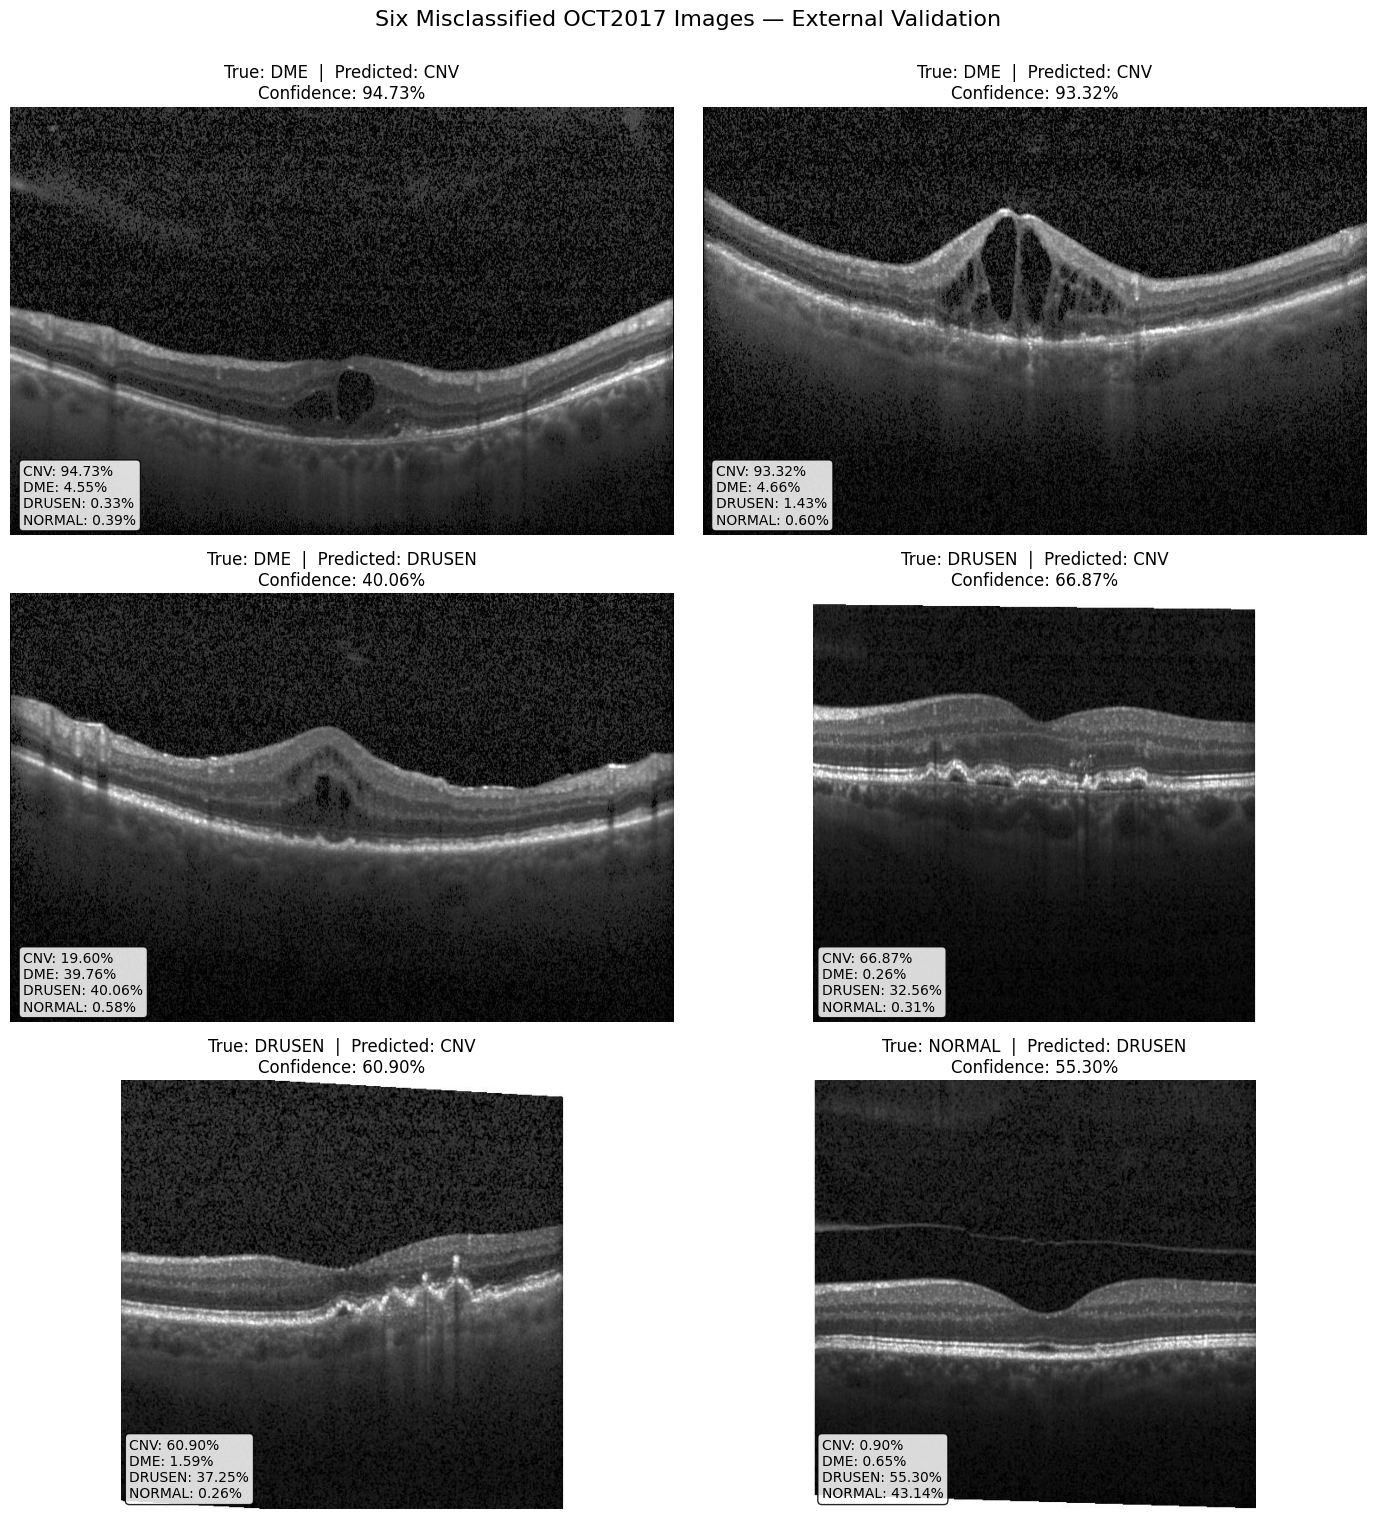

In [41]:
# ================================================================
# VISUAL ERROR ANALYSIS — SIX OCT2017 MISCLASSIFICATIONS
# ================================================================

from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import math

CLASS_NAMES = ["CNV", "DME", "DRUSEN", "NORMAL"]

n_errors = len(error_df)

cols = 2
rows = math.ceil(n_errors / cols)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(14, 5 * rows)
)

axes = np.asarray(axes).reshape(-1)

for plot_idx, (_, row) in enumerate(error_df.iterrows()):

    idx = int(row["Index"])

    image_path = row["Image Path"]

    true_idx = int(y_true[idx])
    pred_idx = int(target_pred_indices[idx])

    probs_i = np.asarray(
        target_probs[idx]
    )

    # Load original OCT image
    image = Image.open(
        image_path
    ).convert("L")

    # Display image
    axes[plot_idx].imshow(
        image,
        cmap="gray"
    )

    # Main title
    axes[plot_idx].set_title(
        f"True: {CLASS_NAMES[true_idx]}  |  "
        f"Predicted: {CLASS_NAMES[pred_idx]}\n"
        f"Confidence: {np.max(probs_i)*100:.2f}%",
        fontsize=12
    )

    axes[plot_idx].axis("off")

    # Probability text
    probability_text = "\n".join([
        f"{CLASS_NAMES[j]}: {probs_i[j]*100:.2f}%"
        for j in range(len(CLASS_NAMES))
    ])

    axes[plot_idx].text(
        0.02,
        0.02,
        probability_text,
        transform=axes[plot_idx].transAxes,
        fontsize=10,
        verticalalignment="bottom",
        bbox=dict(
            boxstyle="round",
            facecolor="white",
            alpha=0.85
        )
    )


# Hide unused axes
for i in range(
    n_errors,
    len(axes)
):
    axes[i].axis("off")


plt.suptitle(
    "Six Misclassified OCT2017 Images — External Validation",
    fontsize=16,
    y=1.01
)

plt.tight_layout()

plt.savefig(
    "OCT2017_six_misclassified_images_detailed.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [42]:
# ================================================================
# DETAILED ERROR ANALYSIS TABLE
# ================================================================

error_analysis_rows = []

for _, row in error_df.iterrows():

    idx = int(row["Index"])

    probs_i = np.asarray(
        target_probs[idx]
    )

    error_analysis_rows.append({

        "Image Index": idx,

        "True Class": CLASS_NAMES[
            int(y_true[idx])
        ],

        "Predicted Class": CLASS_NAMES[
            int(target_pred_indices[idx])
        ],

        "Prediction Confidence": np.max(
            probs_i
        ),

        "CNV Probability": probs_i[0],

        "DME Probability": probs_i[1],

        "DRUSEN Probability": probs_i[2],

        "NORMAL Probability": probs_i[3],

        "True Class Probability": probs_i[
            int(y_true[idx])
        ]
    })


detailed_error_df = pd.DataFrame(
    error_analysis_rows
)

display(
    detailed_error_df.style.format({
        "Prediction Confidence": "{:.2%}",
        "CNV Probability": "{:.2%}",
        "DME Probability": "{:.2%}",
        "DRUSEN Probability": "{:.2%}",
        "NORMAL Probability": "{:.2%}",
        "True Class Probability": "{:.2%}"
    })
)

,Image Index,True Class,Predicted Class,Prediction Confidence,CNV Probability,DME Probability,DRUSEN Probability,NORMAL Probability,True Class Probability
0,287,DME,CNV,94.73%,94.73%,4.55%,0.33%,0.39%,4.55%
1,331,DME,CNV,93.32%,93.32%,4.66%,1.43%,0.60%,4.66%
2,364,DME,DRUSEN,40.06%,19.60%,39.76%,40.06%,0.58%,39.76%
3,700,DRUSEN,CNV,66.87%,66.87%,0.26%,32.56%,0.31%,32.56%
4,723,DRUSEN,CNV,60.90%,60.90%,1.59%,37.25%,0.26%,37.25%
5,782,NORMAL,DRUSEN,55.30%,0.90%,0.65%,55.30%,43.14%,43.14%


In [43]:
# ================================================================
# CREATE COMPLETE KAGGLE RESEARCH ARCHIVE
# ================================================================

from pathlib import Path
import shutil
import os
from datetime import datetime

WORK_DIR = Path("/kaggle/working")

ARCHIVE_DIR = WORK_DIR / "OCT_C8_OCT2017_FINAL_ARCHIVE"
ARCHIVE_DIR.mkdir(parents=True, exist_ok=True)

print("=" * 80)
print("CREATING COMPLETE RESEARCH ARCHIVE")
print("=" * 80)

# ------------------------------------------------
# Copy everything currently in /kaggle/working
# except the archive itself
# ------------------------------------------------

for item in WORK_DIR.iterdir():

    if item.name == ARCHIVE_DIR.name:
        continue

    destination = ARCHIVE_DIR / item.name

    try:

        if item.is_dir():
            shutil.copytree(
                item,
                destination,
                dirs_exist_ok=True
            )

        else:
            shutil.copy2(
                item,
                destination
            )

    except Exception as e:

        print(f"Could not copy {item}: {e}")


# ------------------------------------------------
# Create archive metadata
# ------------------------------------------------

metadata_file = ARCHIVE_DIR / "ARCHIVE_INFO.txt"

with open(
    metadata_file,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "OCT-C8 → OCT2017 EXTERNAL CROSS-DATASET VALIDATION\n"
    )

    f.write("=" * 70 + "\n\n")

    f.write(
        f"Archive created: "
        f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n\n"
    )

    f.write("Experiment:\n")
    f.write("Training dataset: OCT-C8\n")
    f.write("External test dataset: OCT2017\n")
    f.write("Training during external test: NONE\n")
    f.write("Fine-tuning during external test: NONE\n\n")

    f.write("External test set:\n")
    f.write("Images evaluated: 968\n")
    f.write("Classes: CNV, DME, DRUSEN, NORMAL\n\n")

    f.write("Final performance:\n")
    f.write("Accuracy: 99.38%\n")
    f.write("95% Wilson CI: 98.65% – 99.72%\n")
    f.write("Macro Precision: 99.39%\n")
    f.write("Macro Recall: 99.38%\n")
    f.write("Macro F1: 99.38%\n")
    f.write("Macro F1 Bootstrap 95% CI: 98.85% – 99.80%\n")
    f.write("Macro ROC-AUC: 0.9999\n")
    f.write("Macro ROC-AUC Bootstrap 95% CI: 0.9998 – 1.0000\n")
    f.write("MCC: 0.9918\n")
    f.write("Cohen's Kappa: 0.9917\n")
    f.write("Native 8-class compatible: 100%\n")
    f.write("Out-of-target: 0%\n\n")

    f.write("Confusion matrix:\n")
    f.write("CNV:    242  0    0    0\n")
    f.write("DME:    2    239  1    0\n")
    f.write("DRUSEN: 2    0    240  0\n")
    f.write("NORMAL: 0    0    1    241\n\n")

    f.write("Calibration:\n")
    f.write("ECE: 0.024623\n")
    f.write("MCE: 0.248466\n")
    f.write("Multiclass Brier Score: 0.011059\n")


print()
print("Archive created:")
print(ARCHIVE_DIR)

print()
print("Archive contents:")
for item in sorted(ARCHIVE_DIR.rglob("*")):

    if item.is_file():

        print(
            item.relative_to(ARCHIVE_DIR)
        )

CREATING COMPLETE RESEARCH ARCHIVE

Archive created:
/kaggle/working/OCT_C8_OCT2017_FINAL_ARCHIVE

Archive contents:
.virtual_documents/__notebook_source__.ipynb
ARCHIVE_INFO.txt
OCT2017_confidence_distribution.png
OCT2017_reliability_diagram.png
OCT2017_six_misclassified_images_detailed.png
figures/OCT2017_cross_dataset_ROC_curves.png
figures/OCT2017_cross_dataset_confusion_matrix.png
logs/experiment_configuration.json
results/OCT2017_cross_dataset_classification_report.csv
results/OCT2017_cross_dataset_confusion_matrix.csv
results/OCT2017_cross_dataset_metrics.json
results/OCT2017_cross_dataset_predictions.csv


In [44]:
# ================================================================
# CREATE ZIP BACKUP
# ================================================================

import shutil

zip_base = "/kaggle/working/OCT_C8_OCT2017_FINAL_ARCHIVE"

zip_path = shutil.make_archive(
    zip_base,
    "zip",
    "/kaggle/working",
    "OCT_C8_OCT2017_FINAL_ARCHIVE"
)

print("=" * 70)
print("ZIP BACKUP CREATED")
print("=" * 70)
print(zip_path)

ZIP BACKUP CREATED
/kaggle/working/OCT_C8_OCT2017_FINAL_ARCHIVE.zip


In [45]:
# ================================================================
# ORGANIZE FINAL RESEARCH RESULTS
# ================================================================

from pathlib import Path
import shutil

WORK_DIR = Path("/kaggle/working")

FINAL_DIR = WORK_DIR / "FINAL_RESEARCH_RESULTS"

FINAL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Copy important files if they exist
important_files = [
    "OCT2017_reliability_diagram.png",
    "OCT2017_confidence_distribution.png",
    "OCT2017_six_misclassified_images_detailed.png",
    "OCT2017_six_misclassified_images.png",
    "OCT2017_misclassified_images.csv",
]

for filename in important_files:

    source = WORK_DIR / filename

    if source.exists():

        shutil.copy2(
            source,
            FINAL_DIR / filename
        )

        print("Copied:", filename)

print()
print("Final research results directory:")
print(FINAL_DIR)

Copied: OCT2017_reliability_diagram.png
Copied: OCT2017_confidence_distribution.png
Copied: OCT2017_six_misclassified_images_detailed.png

Final research results directory:
/kaggle/working/FINAL_RESEARCH_RESULTS


In [46]:
# ================================================================
# SAVE STATISTICAL RESULTS
# ================================================================

import pandas as pd

FINAL_DIR = Path(
    "/kaggle/working/FINAL_RESEARCH_RESULTS"
)

# Overall results
overall_results = pd.DataFrame([{

    "Total Images": total,
    "Correct Predictions": correct,
    "Incorrect Predictions": total - correct,

    "Accuracy": accuracy,

    "Accuracy 95% CI Lower": acc_ci_low,
    "Accuracy 95% CI Upper": acc_ci_high,

    "Macro Precision": macro_precision,
    "Macro Recall": macro_recall,
    "Macro F1": macro_f1,

    "Weighted Precision": weighted_precision,
    "Weighted Recall": weighted_recall,
    "Weighted F1": weighted_f1,

    "MCC": mcc,
    "Cohen Kappa": cohen_kappa,

    "Macro F1 Bootstrap CI Lower": f1_ci_low,
    "Macro F1 Bootstrap CI Upper": f1_ci_high,

    "Macro ROC AUC": roc_auc,

    "Macro ROC AUC Bootstrap CI Lower": auc_ci_low,
    "Macro ROC AUC Bootstrap CI Upper": auc_ci_high,

    "ECE": ece,
    "MCE": mce,
    "Brier Score": brier_score
}])

overall_results.to_csv(
    FINAL_DIR / "OCT2017_final_statistical_results.csv",
    index=False
)

# Per-class results
per_class_stats.to_csv(
    FINAL_DIR / "OCT2017_per_class_statistics.csv",
    index=False
)

print("Saved:")
print("  OCT2017_final_statistical_results.csv")
print("  OCT2017_per_class_statistics.csv")

Saved:
  OCT2017_final_statistical_results.csv
  OCT2017_per_class_statistics.csv


In [47]:
# ================================================================
# SAVE CONFUSION MATRIX
# ================================================================

cm_df = pd.DataFrame(
    cm,
    index=CLASS_NAMES,
    columns=CLASS_NAMES
)

cm_df.index.name = "True Class"
cm_df.columns.name = "Predicted Class"

cm_df.to_csv(
    FINAL_DIR / "OCT2017_confusion_matrix.csv"
)

print(
    "Saved: OCT2017_confusion_matrix.csv"
)

display(cm_df)

Saved: OCT2017_confusion_matrix.csv


Predicted Class,CNV,DME,DRUSEN,NORMAL
True Class,,,,
CNV,242,0,0,0
DME,2,239,1,0
DRUSEN,2,0,240,0
NORMAL,0,0,1,241


In [48]:
# ================================================================
# SAVE SIX MISCLASSIFICATIONS
# ================================================================

detailed_error_df.to_csv(
    FINAL_DIR / "OCT2017_six_misclassifications.csv",
    index=False
)

print(
    "Saved: OCT2017_six_misclassifications.csv"
)

Saved: OCT2017_six_misclassifications.csv


In [49]:
# ================================================================
# SAVE CALIBRATION RESULTS
# ================================================================

calibration_df.to_csv(
    FINAL_DIR / "OCT2017_calibration_table.csv",
    index=False
)

print(
    "Saved: OCT2017_calibration_table.csv"
)

Saved: OCT2017_calibration_table.csv
